In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from dnsmex.local import localify
from utils import is_in_cdr, sort_antibody_sites, GERMLINE_PATH_DICTIONARY, add_cdr_shading
from dnsmex.koenig_helper import KoenigDataset



In [2]:
# koenig concensus seq, IGHV3
koenig_anarci_chothia = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/koenig/koenig_concensus_anarci_output_H_chothia.csv')
koenig_anarci_chothia = koenig_anarci_chothia.T

# Find the position where index equals 1
start_pos = koenig_anarci_chothia.index.get_loc('1')

# Keep everything from that position onward
koenig_anarci_chothia = koenig_anarci_chothia.iloc[start_pos:]

koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.index = koenig_anarci_chothia.index + 1
koenig_anarci_chothia.rename(columns={'index': 'chothia_site'}, inplace=True)
koenig_anarci_chothia.drop(columns=[0], inplace=True)
koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.rename(columns={'index': 'koenig_index'}, inplace=True)
koenig_anarci_chothia

,koenig_index,chothia_site
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
...,...,...
115,116,109
116,117,110
117,118,111
118,119,112


In [3]:
## with Koenig dataframe


binding_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/binding/Koenig2017_g6_Kd.csv"),
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
)

expr_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/expression/Koenig2017_g6_er.csv"), 
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
    )

binding_df = pd.merge(binding_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')
expression_df = pd.merge(expr_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')

binding_df['log_fitness'] = np.log(binding_df.fitness)
expression_df['log_fitness'] = np.log(expression_df.fitness)



In [4]:
## aggregate fitness per site, as the mutations present do not show all entrenched possibilities

In [5]:
fitness_df = pd.merge(binding_df.groupby('chothia_site').log_fitness.mean().reset_index(), expression_df.groupby('chothia_site').log_fitness.mean().reset_index(), on='chothia_site', suffixes=('_binding', '_expression'))
fitness_df

,chothia_site,log_fitness_binding,log_fitness_expression
0,10,-0.327888,0.229007
1,100,-2.138957,-1.320900
2,100A,-1.225351,-0.134102
3,100B,-3.666193,-0.469191
4,100C,-0.976824,-0.264573
...,...,...,...
114,95,-3.198672,-0.284015
115,96,-2.844174,-0.239277
116,97,-1.902043,0.065033
117,98,-3.472526,0.188595


In [6]:
entrenched_within = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_within_IGHV3.csv', dtype={'site':str})
entrenched_between = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_IGHV1_vs_IGHV3.csv', dtype={'site':str})    
entrenched_between = entrenched_between[entrenched_between['v_family']=='IGHV3']



Statistical test results (Mann-Whitney U test, non-entrenched vs entrenched):
Within V family - Binding: p = 7.20e-03, r = -0.681, n = (114, 5)
Within V family - Expression: p = 8.02e-01, r = -0.070, n = (114, 5)
Between V families - Binding: p = 2.57e-02, r = -0.468, n = (111, 8)
Between V families - Expression: p = 5.77e-01, r = -0.122, n = (111, 8)


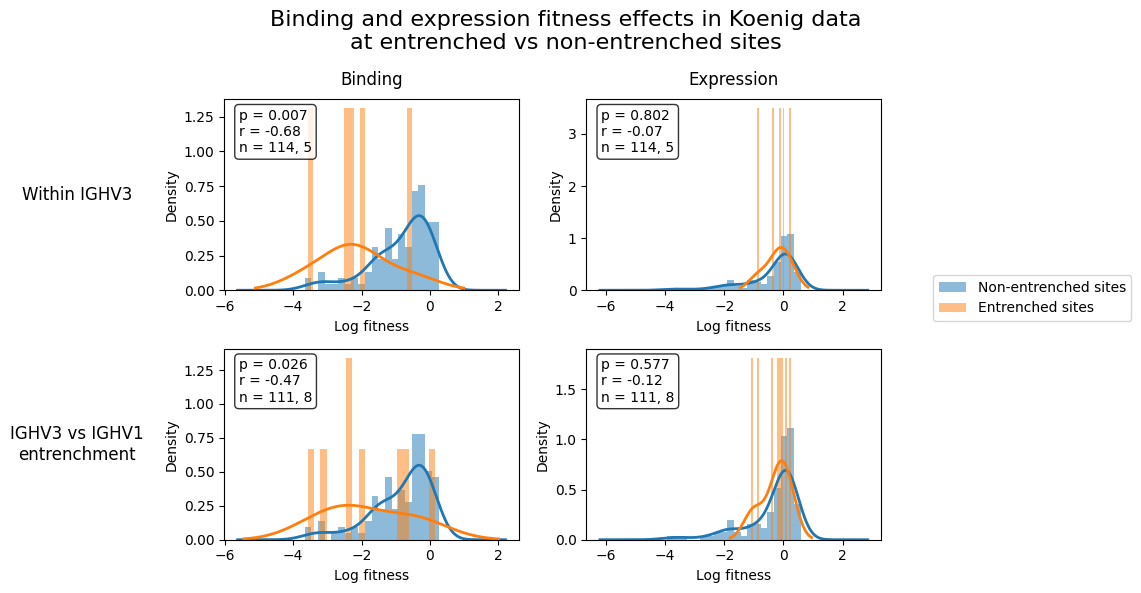

In [7]:
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Get first two colors from tab10
colors = plt.cm.tab10.colors
color_non_entrenched = colors[0]
color_entrenched = colors[1]

# Row 1: Within IGHV3 entrenched
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_within.site)]
non_entrenched_fitness_df = fitness_df[~fitness_df.chothia_site.isin(entrenched_within.site)]

# Binding fitness
non_entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_entrenched, legend=False)
axes[0,0].set_xlabel('Log fitness')
axes[0,0].set_ylabel('Density')

# Statistical test - binding (within)
stat_binding_within, p_binding_within = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
# Calculate effect size (rank-biserial correlation)
n1_binding_within = len(non_entrenched_fitness_df.log_fitness_binding.dropna())
n2_binding_within = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_within = 1 - (2*stat_binding_within) / (n1_binding_within * n2_binding_within)

# Add p-value, effect size, and sample sizes to plot
p_text = f'p = {p_binding_within:.2e}' if p_binding_within < 0.001 else f'p = {p_binding_within:.3f}'
effect_text = f'r = {r_binding_within:.2f}'
n_text = f'n = {n1_binding_within}, {n2_binding_within}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[0,0].text(0.05, 0.95, combined_text, transform=axes[0,0].transAxes, 
               fontsize=10, va='top', ha='left', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
non_entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_entrenched, legend=False)
axes[0,1].set_xlabel('Log fitness')
axes[0,1].set_ylabel('Density')

# Statistical test - expression (within)
stat_expr_within, p_expr_within = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1_expr_within = len(non_entrenched_fitness_df.log_fitness_expression.dropna())
n2_expr_within = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_within = 1 - (2*stat_expr_within) / (n1_expr_within * n2_expr_within)

p_text = f'p = {p_expr_within:.2e}' if p_expr_within < 0.001 else f'p = {p_expr_within:.3f}'
effect_text = f'r = {r_expr_within:.2f}'
n_text = f'n = {n1_expr_within}, {n2_expr_within}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[0,1].text(0.05, 0.95, combined_text, transform=axes[0,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Row 2: Between IGHV1 and IGHV3
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_between.site)]
non_entrenched_fitness_df = fitness_df[~fitness_df.chothia_site.isin(entrenched_between.site)]

# Binding fitness
non_entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_entrenched, legend=False)
axes[1,0].set_xlabel('Log fitness')
axes[1,0].set_ylabel('Density')

# Statistical test - binding (between)
stat_binding_between, p_binding_between = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
n1_binding_between = len(non_entrenched_fitness_df.log_fitness_binding.dropna())
n2_binding_between = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_between = 1 - (2*stat_binding_between) / (n1_binding_between * n2_binding_between)

p_text = f'p = {p_binding_between:.2e}' if p_binding_between < 0.001 else f'p = {p_binding_between:.3f}'
effect_text = f'r = {r_binding_between:.2f}'
n_text = f'n = {n1_binding_between}, {n2_binding_between}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[1,0].text(0.05, 0.95, combined_text, transform=axes[1,0].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
non_entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_entrenched, legend=False)
axes[1,1].set_xlabel('Log fitness')
axes[1,1].set_ylabel('Density')

# Statistical test - expression (between)
stat_expr_between, p_expr_between = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1_expr_between = len(non_entrenched_fitness_df.log_fitness_expression.dropna())
n2_expr_between = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_between = 1 - (2*stat_expr_between) / (n1_expr_between * n2_expr_between)

p_text = f'p = {p_expr_between:.2e}' if p_expr_between < 0.001 else f'p = {p_expr_between:.3f}'
effect_text = f'r = {r_expr_between:.2f}'
n_text = f'n = {n1_expr_between}, {n2_expr_between}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[1,1].text(0.05, 0.95, combined_text, transform=axes[1,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Column titles
axes[0,0].set_title('Binding', fontsize=12, pad=10)
axes[0,1].set_title('Expression', fontsize=12, pad=10)

# Row titles (on the left side, horizontal)
axes[0,0].text(-0.5, 0.5, 'Within IGHV3', transform=axes[0,0].transAxes, 
               fontsize=12, va='center', ha='center')
axes[1,0].text(-0.5, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1,0].transAxes, 
               fontsize=12, va='center', ha='center')

# Get only histogram handles (first 2) from legend
handles, labels = axes[0,0].get_legend_handles_labels()
legend = fig.legend(handles[:2], labels[:2], loc='center left', bbox_to_anchor=(0.9, 0.5))

# Remove individual legends
for ax_row in axes:
    for ax in ax_row:
        if ax.get_legend():
            ax.legend().remove()

fig.suptitle('Binding and expression fitness effects in Koenig data\nat entrenched vs non-entrenched sites', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.12, right=0.85)  # Make room for row titles and legend

# Print summary of statistical tests
print("\nStatistical test results (Mann-Whitney U test, non-entrenched vs entrenched):")
print(f"Within V family - Binding: p = {p_binding_within:.2e}, r = {r_binding_within:.3f}, n = ({n1_binding_within}, {n2_binding_within})")
print(f"Within V family - Expression: p = {p_expr_within:.2e}, r = {r_expr_within:.3f}, n = ({n1_expr_within}, {n2_expr_within})")
print(f"Between V families - Binding: p = {p_binding_between:.2e}, r = {r_binding_between:.3f}, n = ({n1_binding_between}, {n2_binding_between})")
print(f"Between V families - Expression: p = {p_expr_between:.2e}, r = {r_expr_between:.3f}, n = ({n1_expr_between}, {n2_expr_between})")

plt.show()
fig.savefig('figures/koenig_binding_expression_fitness_entrenchment_histograms.png', dpi=800, bbox_inches='tight')

In [8]:
### individual mutations

fitness_df = pd.merge(binding_df, expression_df, on=['chothia_site', 'site', 'difference', 'aa'], suffixes=('_binding', '_expression'))
fitness_df['amino_acid'] = fitness_df.difference.str[0]
fitness_df.rename(columns={'aa':'target_amino_acid'}, inplace=True)
fitness_df


,heavy_binding,light_binding,fitness_binding,heavy_differences_binding,light_differences_binding,heavy_difference_count_binding,light_difference_count_binding,difference_count_binding,difference,site,...,heavy_expression,light_expression,fitness_expression,heavy_differences_expression,light_differences_expression,heavy_difference_count_expression,light_difference_count_expression,difference_count_expression,log_fitness_expression,amino_acid
0,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,3.620218,[V2A],[],1,0,1,V2A,2,...,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.819679,[V2A],[],1,0,1,-0.198843,V
1,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.142127,[V2C],[],1,0,1,V2C,2,...,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.328397,[V2C],[],1,0,1,-1.113532,V
2,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.378990,[V2D],[],1,0,1,V2D,2,...,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.585834,[V2D],[],1,0,1,0.461110,V
3,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.578943,[V2E],[],1,0,1,V2E,2,...,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.806183,[V2E],[],1,0,1,0.591216,V
4,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.806596,[V2F],[],1,0,1,V2F,2,...,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.452152,[V2F],[],1,0,1,0.373046,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.324930,[S120R],[],1,0,1,S120R,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.780243,[S120R],[],1,0,1,0.576750,S
2257,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.376044,[S120T],[],1,0,1,S120T,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.461977,[S120T],[],1,0,1,0.379790,S
2258,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.835231,[S120V],[],1,0,1,S120V,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.177392,[S120V],[],1,0,1,0.163302,S
2259,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.326943,[S120W],[],1,0,1,S120W,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.129685,[S120W],[],1,0,1,0.121939,S


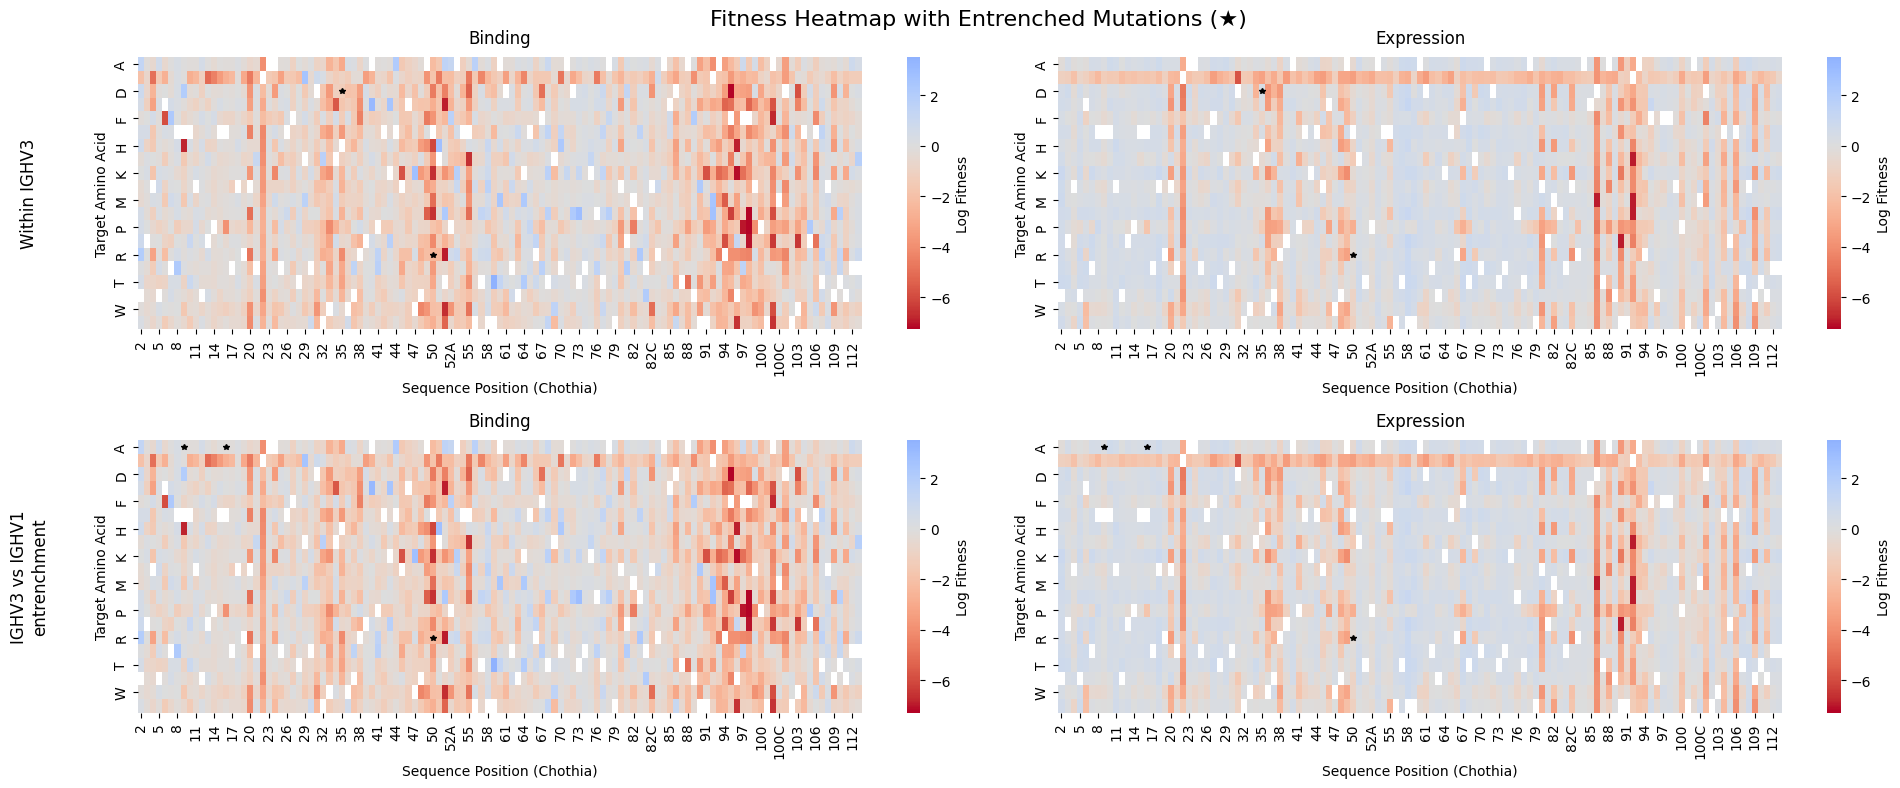

In [9]:
# Fitness Heatmap with Entrenched Mutations marked with stars
# 2x2 grid: rows = entrenchment type (within/between), columns = fitness type (binding/expression)

from utils import sort_antibody_sites

# Create pivot tables for heatmaps
heatmap_binding = fitness_df.pivot_table(
    index='target_amino_acid',
    columns='chothia_site',
    values='log_fitness_binding'
)
heatmap_expression = fitness_df.pivot_table(
    index='target_amino_acid',
    columns='chothia_site',
    values='log_fitness_expression'
)

# Sort columns by antibody site order
sorted_sites = sort_antibody_sites(heatmap_binding.columns.tolist())
heatmap_binding = heatmap_binding[sorted_sites]
heatmap_expression = heatmap_expression[sorted_sites]

# Sort amino acids alphabetically for consistent y-axis
aa_order = sorted(heatmap_binding.index.tolist())
heatmap_binding = heatmap_binding.reindex(aa_order)
heatmap_expression = heatmap_expression.reindex(aa_order)

# Get entrenched positions for marking with stars
entrenched_within_positions = pd.merge(
    fitness_df, 
    entrenched_within.rename(columns={'site':'chothia_site'}), 
    on=['chothia_site', 'amino_acid', 'target_amino_acid']
)[['chothia_site', 'target_amino_acid']].drop_duplicates()

entrenched_between_positions = pd.merge(
    fitness_df, 
    entrenched_between.rename(columns={'site':'chothia_site'}), 
    on=['chothia_site', 'amino_acid', 'target_amino_acid']
)[['chothia_site', 'target_amino_acid']].drop_duplicates()

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(20, 8))

# Color limits (shared across all heatmaps)
vmin = min(heatmap_binding.min().min(), heatmap_expression.min().min())
vmax = max(heatmap_binding.max().max(), heatmap_expression.max().max())

def plot_heatmap_with_stars(ax, heatmap_data, entrenched_positions, title):
    """Plot heatmap and overlay stars at entrenched positions."""
    sns.heatmap(heatmap_data, ax=ax, cmap='coolwarm_r', center=0,
                vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Log Fitness'})
    
    # Add stars at entrenched positions
    for _, row in entrenched_positions.iterrows():
        site = row['chothia_site']
        aa = row['target_amino_acid']
        
        if site in heatmap_data.columns and aa in heatmap_data.index:
            x_pos = list(heatmap_data.columns).index(site) + 0.5
            y_pos = list(heatmap_data.index).index(aa) + 0.5
            ax.plot(x_pos, y_pos, marker='*', color='black', markersize=4)
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Sequence Position (Chothia)')
    ax.set_ylabel('Target Amino Acid')

# Row 1: Within IGHV3 entrenchment
plot_heatmap_with_stars(axes[0, 0], heatmap_binding, entrenched_within_positions, 'Binding')
plot_heatmap_with_stars(axes[0, 1], heatmap_expression, entrenched_within_positions, 'Expression')

# Row 2: Between IGHV1 vs IGHV3 entrenchment
plot_heatmap_with_stars(axes[1, 0], heatmap_binding, entrenched_between_positions, 'Binding')
plot_heatmap_with_stars(axes[1, 1], heatmap_expression, entrenched_between_positions, 'Expression')

# Row titles
axes[0, 0].text(-0.15, 0.5, 'Within IGHV3', transform=axes[0, 0].transAxes, 
                fontsize=12, va='center', ha='center', rotation=90)
axes[1, 0].text(-0.15, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1, 0].transAxes, 
                fontsize=12, va='center', ha='center', rotation=90)

fig.suptitle('Fitness Heatmap with Entrenched Mutations (★)', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.08, top=0.92)
fig.show()
fig.savefig('figures/koenig_fitness_heatmap_entrenched.png', dpi=300, bbox_inches='tight')

## Binding vs Expression Tradeoff Analysis

For each single mutation in the Koenig deep mutational scan, we ask: how often does a mutation that improves binding hurt expression (or vice versa)?

Mutations are classified into four quadrants based on whether their log fitness effect on binding and expression is positive or negative relative to wildtype (log fitness = 0).

In [10]:
from scipy.stats import pearsonr, spearmanr

# Use the per-mutation fitness_df from the cell above
df = fitness_df[['chothia_site', 'difference', 'amino_acid', 'target_amino_acid',
                 'log_fitness_binding', 'log_fitness_expression']].dropna()

# Classify mutations into quadrants
def classify_quadrant(row):
    b = row['log_fitness_binding']
    e = row['log_fitness_expression']
    if b > 0 and e > 0:
        return 'Both improve'
    elif b > 0 and e <= 0:
        return 'Binding up, Expression down'
    elif b <= 0 and e > 0:
        return 'Binding down, Expression up'
    else:
        return 'Both worsen'

df['quadrant'] = df.apply(classify_quadrant, axis=1)

# Count mutations in each quadrant
quadrant_counts = df['quadrant'].value_counts()
quadrant_pcts = (quadrant_counts / len(df) * 100).round(1)

print("Mutation counts by quadrant:")
for q in ['Both improve', 'Binding up, Expression down', 
          'Binding down, Expression up', 'Both worsen']:
    n = quadrant_counts.get(q, 0)
    pct = quadrant_pcts.get(q, 0)
    print(f"  {q}: {n} ({pct}%)")

tradeoff_count = (quadrant_counts.get('Binding up, Expression down', 0) + 
                  quadrant_counts.get('Binding down, Expression up', 0))
tradeoff_pct = tradeoff_count / len(df) * 100
print(f"\nTotal tradeoff mutations (one up, other down): {tradeoff_count} ({tradeoff_pct:.1f}%)")

# Correlation
r_pearson, p_pearson = pearsonr(df['log_fitness_binding'], df['log_fitness_expression'])
r_spearman, p_spearman = spearmanr(df['log_fitness_binding'], df['log_fitness_expression'])
print(f"\nPearson r = {r_pearson:.3f} (p = {p_pearson:.2e})")
print(f"Spearman rho = {r_spearman:.3f} (p = {p_spearman:.2e})")

Mutation counts by quadrant:
  Both improve: 415 (18.4%)
  Binding up, Expression down: 84 (3.7%)
  Binding down, Expression up: 819 (36.2%)
  Both worsen: 943 (41.7%)

Total tradeoff mutations (one up, other down): 903 (39.9%)

Pearson r = 0.423 (p = 1.24e-98)
Spearman rho = 0.582 (p = 8.55e-205)


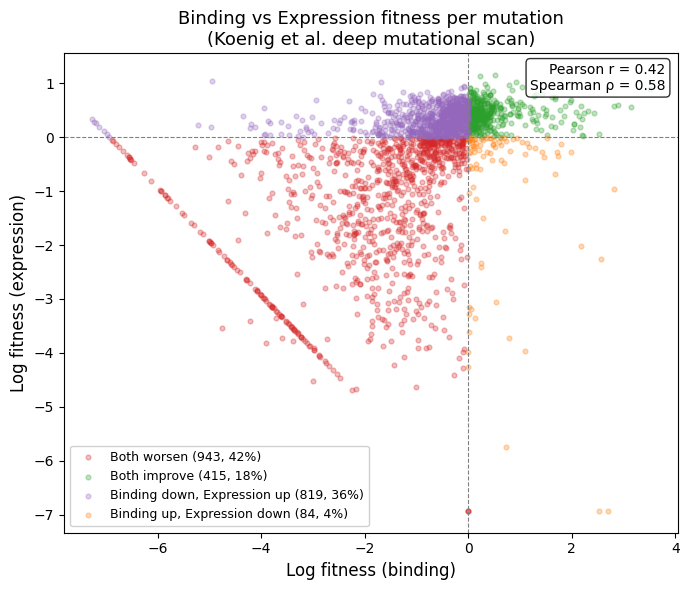

In [11]:
# Scatter plot: binding vs expression fitness per mutation
quadrant_colors = {
    'Both improve': '#2ca02c',
    'Both worsen': '#d62728',
    'Binding up, Expression down': '#ff7f0e',
    'Binding down, Expression up': '#9467bd',
}
quadrant_order = ['Both worsen', 'Both improve', 
                  'Binding down, Expression up', 'Binding up, Expression down']

fig, ax = plt.subplots(figsize=(7, 6))

for q in quadrant_order:
    subset = df[df['quadrant'] == q]
    n = len(subset)
    pct = n / len(df) * 100
    ax.scatter(subset['log_fitness_binding'], subset['log_fitness_expression'],
               alpha=0.3, s=12, color=quadrant_colors[q],
               label=f'{q} ({n}, {pct:.0f}%)')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

ax.set_xlabel('Log fitness (binding)', fontsize=12)
ax.set_ylabel('Log fitness (expression)', fontsize=12)
ax.set_title('Binding vs Expression fitness per mutation\n(Koenig et al. deep mutational scan)', fontsize=13)

ax.legend(fontsize=9, loc='lower left', framealpha=0.9)

# Annotate with correlation
ax.text(0.98, 0.98, f'Pearson r = {r_pearson:.2f}\nSpearman ρ = {r_spearman:.2f}',
        transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()



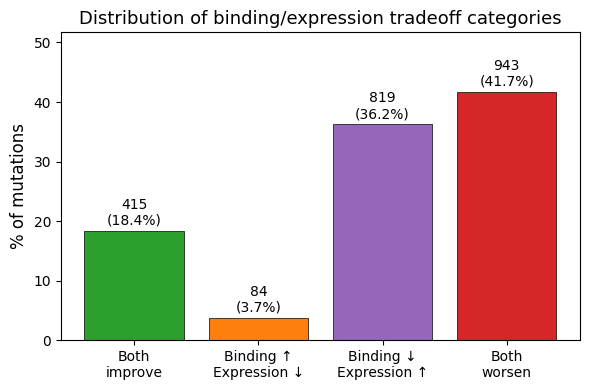

In [12]:
# Bar chart of quadrant proportions
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Both\nimprove', 'Binding ↑\nExpression ↓', 'Binding ↓\nExpression ↑', 'Both\nworsen']
keys = ['Both improve', 'Binding up, Expression down', 
        'Binding down, Expression up', 'Both worsen']
colors_bar = [quadrant_colors[k] for k in keys]
counts = [quadrant_counts.get(k, 0) for k in keys]
pcts = [c / len(df) * 100 for c in counts]

bars = ax.bar(labels, pcts, color=colors_bar, edgecolor='black', linewidth=0.5)

for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('% of mutations', fontsize=12)
ax.set_title('Distribution of binding/expression tradeoff categories', fontsize=13)
ax.set_ylim(0, max(pcts) + 10)

plt.tight_layout()
plt.show()


In [13]:
# Among mutations that improve binding, what fraction hurts expression?
binding_improves = df[df['log_fitness_binding'] > 0]
binding_improves_expr_worsens = binding_improves[binding_improves['log_fitness_expression'] <= 0]
print(f"Mutations that improve binding: {len(binding_improves)}")
print(f"  Of those, expression worsens: {len(binding_improves_expr_worsens)} "
      f"({len(binding_improves_expr_worsens)/len(binding_improves)*100:.1f}%)")
print(f"  Of those, expression also improves: {len(binding_improves) - len(binding_improves_expr_worsens)} "
      f"({(len(binding_improves) - len(binding_improves_expr_worsens))/len(binding_improves)*100:.1f}%)")

print()

# Among mutations that improve expression, what fraction hurts binding?
expr_improves = df[df['log_fitness_expression'] > 0]
expr_improves_binding_worsens = expr_improves[expr_improves['log_fitness_binding'] <= 0]
print(f"Mutations that improve expression: {len(expr_improves)}")
print(f"  Of those, binding worsens: {len(expr_improves_binding_worsens)} "
      f"({len(expr_improves_binding_worsens)/len(expr_improves)*100:.1f}%)")
print(f"  Of those, binding also improves: {len(expr_improves) - len(expr_improves_binding_worsens)} "
      f"({(len(expr_improves) - len(expr_improves_binding_worsens))/len(expr_improves)*100:.1f}%)")

Mutations that improve binding: 499
  Of those, expression worsens: 84 (16.8%)
  Of those, expression also improves: 415 (83.2%)

Mutations that improve expression: 1234
  Of those, binding worsens: 819 (66.4%)
  Of those, binding also improves: 415 (33.6%)


## DASM predictions vs joint binding/expression fitness

Since ~40% of mutations show tradeoffs between binding and expression, we ask whether DASM selection factors—which capture overall fitness effects from natural antibody evolution—correlate better with a joint measure of binding and expression fitness than with either alone.

In [14]:
import torch
from netam.common import heavy_chain_shim
from netam.framework import load_crepe
from netam.sequences import AA_STR_SORTED

# Use the consensus heavy chain derived from the Koenig data
heavy_wt = binding_dataset.heavy_consensus
print(f"Koenig consensus heavy chain ({len(heavy_wt)} aa): {heavy_wt}")

# Load DASM model
crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"))
crepe.model.train()
crepe = heavy_chain_shim(crepe)

# Get DASM log selection factors
[dasm_heavy] = crepe([heavy_wt])
log_dasm = np.log(dasm_heavy.detach().numpy()).T

# DataFrame: rows = amino acids, columns = positions (1-indexed)
dasm_df = pd.DataFrame(log_dasm, columns=range(1, log_dasm.shape[1] + 1), index=list(AA_STR_SORTED))

print(f"DASM output: {len(AA_STR_SORTED)} amino acids x {log_dasm.shape[1]} positions")

Koenig consensus heavy chain (120 aa): EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS
DASM output: 20 amino acids x 120 positions


In [15]:
# Map DASM log selection factor to each Koenig mutation
# site = koenig_index (1-based position), target_amino_acid = mutant AA
fitness_df['dasm_log_sf'] = [
    dasm_df.loc[aa, site] 
    for aa, site in zip(fitness_df['target_amino_acid'], fitness_df['site'])
]

# Joint fitness metrics (log scale)
# Sum of logs = log(binding_fitness × expression_fitness) — multiplicative fitness model
fitness_df['joint_log_sum'] = fitness_df['log_fitness_binding'] + fitness_df['log_fitness_expression']
# Min of logs — bottleneck model (fitness limited by worse component)
fitness_df['joint_log_min'] = fitness_df[['log_fitness_binding', 'log_fitness_expression']].min(axis=1)

# Working dataframe with complete cases
df_corr = fitness_df[['dasm_log_sf', 'log_fitness_binding', 'log_fitness_expression', 
                       'joint_log_sum', 'joint_log_min']].dropna()

print(f"Mutations with complete data: {len(df_corr)} / {len(fitness_df)}")

Mutations with complete data: 2261 / 2261


In [16]:
from scipy.stats import spearmanr, pearsonr

metrics = {
    'Binding': 'log_fitness_binding',
    'Expression': 'log_fitness_expression',
    'Sum (log bind + log expr)': 'joint_log_sum',
    'Min (log bind, log expr)': 'joint_log_min',
}

print("Correlation of DASM log selection factor with Koenig fitness metrics:")
print("=" * 80)
results = []
for label, col in metrics.items():
    rho, p_rho = spearmanr(df_corr['dasm_log_sf'], df_corr[col])
    r, p_r = pearsonr(df_corr['dasm_log_sf'], df_corr[col])
    results.append({'Metric': label, 'Spearman rho': rho, 'p_spearman': p_rho,
                    'Pearson r': r, 'p_pearson': p_r})
    print(f"  {label:30s}  Spearman rho = {rho:.3f} (p={p_rho:.2e}),  Pearson r = {r:.3f} (p={p_r:.2e})")

results_df = pd.DataFrame(results)

Correlation of DASM log selection factor with Koenig fitness metrics:
  Binding                         Spearman rho = 0.324 (p=2.62e-56),  Pearson r = 0.253 (p=2.64e-34)
  Expression                      Spearman rho = 0.529 (p=1.48e-163),  Pearson r = 0.639 (p=1.35e-259)
  Sum (log bind + log expr)       Spearman rho = 0.463 (p=8.87e-121),  Pearson r = 0.507 (p=3.27e-148)
  Min (log bind, log expr)        Spearman rho = 0.432 (p=3.21e-103),  Pearson r = 0.414 (p=2.07e-94)


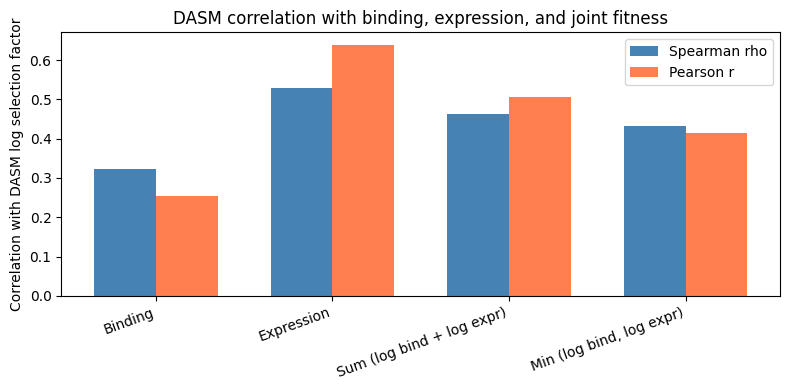

In [17]:
# Bar chart comparing correlations across metrics
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['Spearman rho'], width,
               label='Spearman rho', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], results_df['Pearson r'], width,
               label='Pearson r', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Metric'], rotation=20, ha='right')
ax.set_ylabel('Correlation with DASM log selection factor')
ax.set_title('DASM correlation with binding, expression, and joint fitness')
ax.legend()
ax.axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.show()


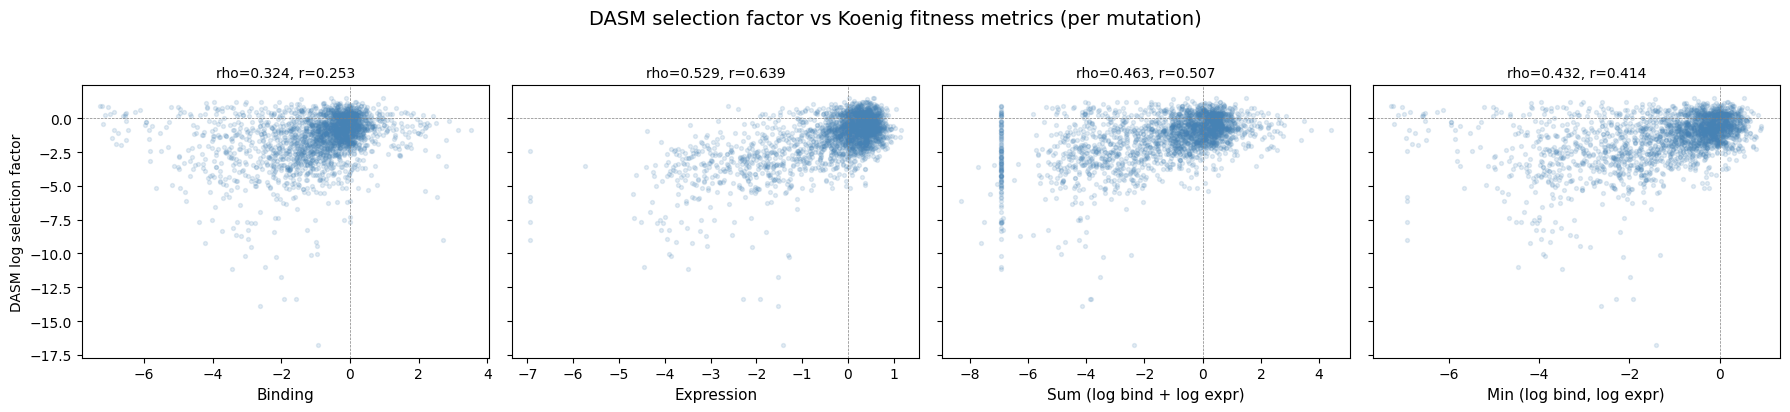

In [18]:
# Scatter panels: DASM log selection factor vs each fitness metric
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, (label, col) in zip(axes, metrics.items()):
    rho, _ = spearmanr(df_corr['dasm_log_sf'], df_corr[col])
    r, _ = pearsonr(df_corr['dasm_log_sf'], df_corr[col])
    ax.scatter(df_corr[col], df_corr['dasm_log_sf'], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f'rho={rho:.3f}, r={r:.3f}', fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

axes[0].set_ylabel('DASM log selection factor')
fig.suptitle('DASM selection factor vs Koenig fitness metrics (per mutation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### CDR vs Framework stratified correlations

DASM correlates much more strongly with expression than binding globally. But does this change by region? In CDRs, antigen-contact selection may dominate, while in framework regions structural constraints drive fitness. Splitting by CDR/framework tests whether DASM picks up binding signal specifically where it matters.

### Results:
The CDR/framework split reveals something important:

Framework (n=1805): All correlations are strong. Expression leads (rho=0.610) but binding is also substantial (0.466), and the joint sum nearly matches expression (0.590).

CDR (n=456): Everything drops dramatically. Binding correlation nearly vanishes (rho=0.101, barely significant). Expression is modest (0.346). Joint metrics don't help.

This actually makes a lot of sense and tells us what DASM is capturing:

DASM can't predict antigen-specific binding. CDR binding fitness in Koenig is measured against a specific antigen (g6). DASM, trained on natural repertoires, has no information about which antigen is being targeted — it only sees which CDR mutations tend to be tolerated in general. So the near-zero CDR binding correlation isn't a failure, it's expected.

The framework binding signal is probably indirect. The decent framework binding correlation (0.466) likely reflects that structurally destabilizing mutations also lose binding — so DASM is capturing stability, which correlates with binding in framework but not CDR.

The joint metrics can't help. Since the binding component adds noise (especially in CDRs), combining it with expression dilutes the signal rather than improving it.

The bottom line: DASM primarily captures structural/expression constraints. Its "binding" correlation is an artifact of stability being a prerequisite for binding, not a prediction of antigen-specific affinity.

In [19]:
# Label each mutation as CDR or framework using Chothia numbering
fitness_df['is_cdr'] = fitness_df['chothia_site'].apply(
    is_in_cdr, numbering_scheme='chothia', chain='heavy'
)
fitness_df['region'] = fitness_df['is_cdr'].map({True: 'CDR', False: 'Framework'})

n_cdr = fitness_df['is_cdr'].sum()
n_fw = (~fitness_df['is_cdr']).sum()
print(f"CDR mutations: {n_cdr}, Framework mutations: {n_fw}")

CDR mutations: 456, Framework mutations: 1805


In [20]:
# Compute correlations stratified by CDR vs Framework
stratified_results = []

for region in ['CDR', 'Framework']:
    subset = fitness_df[fitness_df['region'] == region][
        ['dasm_log_sf', 'log_fitness_binding', 'log_fitness_expression',
         'joint_log_sum', 'joint_log_min']
    ].dropna()
    
    for label, col in metrics.items():
        rho, p_rho = spearmanr(subset['dasm_log_sf'], subset[col])
        r, p_r = pearsonr(subset['dasm_log_sf'], subset[col])
        stratified_results.append({
            'Region': region, 'Metric': label, 'n': len(subset),
            'Spearman rho': rho, 'p_spearman': p_rho,
            'Pearson r': r, 'p_pearson': p_r,
        })

strat_df = pd.DataFrame(stratified_results)

print("DASM correlations stratified by CDR vs Framework:")
print("=" * 90)
for region in ['CDR', 'Framework']:
    sub = strat_df[strat_df['Region'] == region]
    n = sub['n'].iloc[0]
    print(f"\n  {region} (n={n}):")
    for _, row in sub.iterrows():
        print(f"    {row['Metric']:30s}  rho={row['Spearman rho']:.3f} (p={row['p_spearman']:.2e}),  r={row['Pearson r']:.3f} (p={row['p_pearson']:.2e})")

DASM correlations stratified by CDR vs Framework:

  CDR (n=456):
    Binding                         rho=0.011 (p=8.13e-01),  r=-0.062 (p=1.89e-01)
    Expression                      rho=0.328 (p=7.10e-13),  r=0.387 (p=9.73e-18)
    Sum (log bind + log expr)       rho=0.125 (p=7.59e-03),  r=0.107 (p=2.24e-02)
    Min (log bind, log expr)        rho=0.074 (p=1.14e-01),  r=0.012 (p=7.95e-01)

  Framework (n=1805):
    Binding                         rho=0.481 (p=3.48e-105),  r=0.415 (p=3.14e-76)
    Expression                      rho=0.601 (p=6.75e-178),  r=0.669 (p=1.17e-234)
    Sum (log bind + log expr)       rho=0.599 (p=1.57e-176),  r=0.620 (p=3.55e-192)
    Min (log bind, log expr)        rho=0.586 (p=4.26e-167),  r=0.577 (p=8.14e-161)


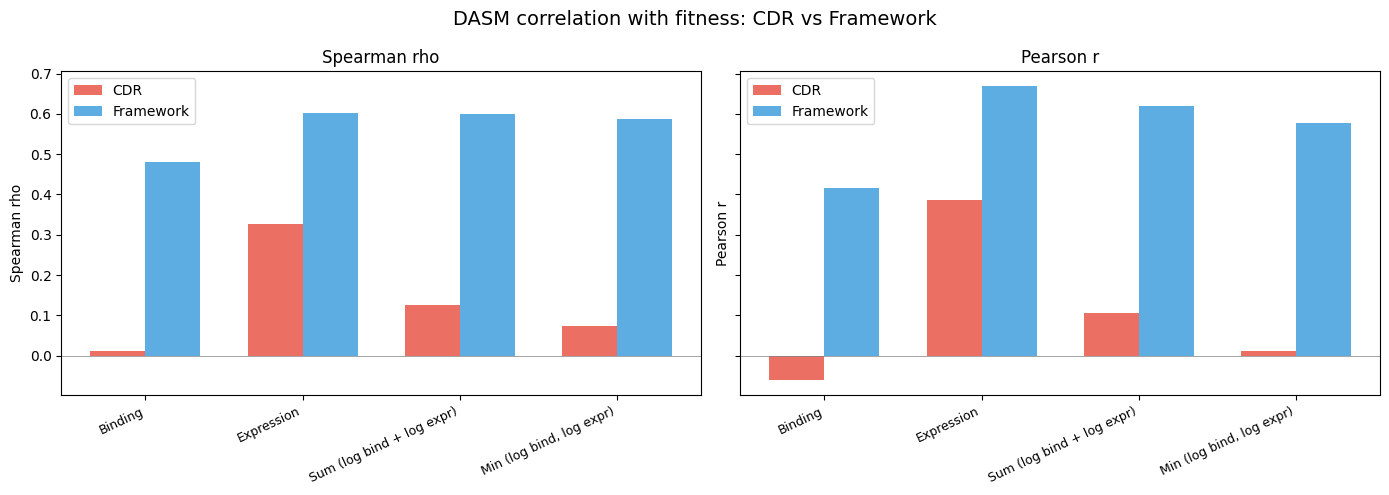

In [21]:
# Grouped bar chart: CDR vs Framework correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, corr_col, corr_label in zip(axes, ['Spearman rho', 'Pearson r'], ['Spearman rho', 'Pearson r']):
    metric_labels = strat_df['Metric'].unique()
    x = np.arange(len(metric_labels))
    width = 0.35
    
    cdr_vals = strat_df[strat_df['Region'] == 'CDR'][corr_col].values
    fw_vals = strat_df[strat_df['Region'] == 'Framework'][corr_col].values
    
    ax.bar(x - width/2, cdr_vals, width, label='CDR', color='#e74c3c', alpha=0.8)
    ax.bar(x + width/2, fw_vals, width, label='Framework', color='#3498db', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(corr_label)
    ax.set_title(corr_label)
    ax.legend()
    ax.axhline(0, color='grey', linewidth=0.5)

fig.suptitle('DASM correlation with fitness: CDR vs Framework', fontsize=14)
plt.tight_layout()
plt.show()


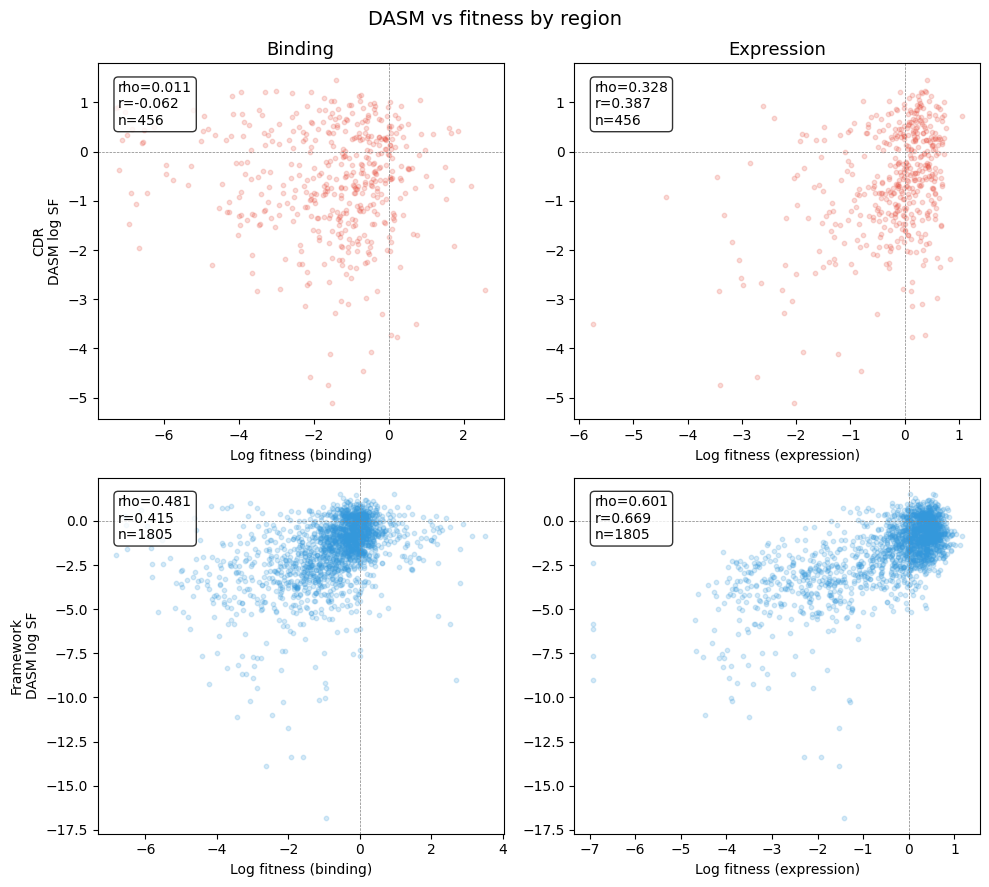

In [22]:
# Scatter panels split by CDR vs Framework: DASM vs binding and expression
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

region_colors = {'CDR': '#e74c3c', 'Framework': '#3498db'}

for col_idx, (fitness_label, fitness_col) in enumerate([
    ('Binding', 'log_fitness_binding'), 
    ('Expression', 'log_fitness_expression')
]):
    for row_idx, region in enumerate(['CDR', 'Framework']):
        ax = axes[row_idx, col_idx]
        subset = fitness_df[fitness_df['region'] == region][
            ['dasm_log_sf', fitness_col]
        ].dropna()
        
        rho, p = spearmanr(subset['dasm_log_sf'], subset[fitness_col])
        r, p_r = pearsonr(subset['dasm_log_sf'], subset[fitness_col])
        
        ax.scatter(subset[fitness_col], subset['dasm_log_sf'], 
                   alpha=0.2, s=10, color=region_colors[region])
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
        
        ax.text(0.05, 0.95, f'rho={rho:.3f}\nr={r:.3f}\nn={len(subset)}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        if row_idx == 0:
            ax.set_title(fitness_label, fontsize=13)
        if col_idx == 0:
            ax.set_ylabel(f'{region}\nDASM log SF')
        ax.set_xlabel(f'Log fitness ({fitness_label.lower()})')

fig.suptitle('DASM vs fitness by region', fontsize=14)
plt.tight_layout()
plt.show()
